In [204]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from WDBinary import WDBinary

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [206]:
def einstein_radius(Mlens = 1.0, dlens=10, a = 1.0, inc=0.0):
    dsource = dlens + a.to(u.pc)
    ratio = np.abs(((a.to(u.pc) * np.cos(inc)) / (dlens * dsource)).to(1 / u.m))

    theta = np.sqrt((4 * G * Mlens.to(u.kg) / c**2) * ratio)
    return (theta * dlens) # but this is point mass

In [207]:
def p_slb(r_E, r_star=1.0*u.Rsun, a=1.0*u.au, e=0.0, f=0.0):
    cosE = (e + np.cos(f)) / (1 + e*np.cos(f))
    denom = a * (1 - e*cosE)
    return (r_E + r_star.to(u.pc)) / denom.to(u.pc)

## Black Hole Dectectability ##

In [208]:
N = 100000  # number of systems

a_min = 1.0  # AU
a_max = 20.0 # AU

a = np.logspace(np.log10(a_min), np.log10(a_max), N) * u.au

Mlens = np.random.uniform(10.0, 33.0, N) * u.Msun

inc = np.random.uniform(0, np.pi, N) 
e = np.random.uniform(0.3, 0.99, N)     # eccentricity
f = np.random.uniform(0, 2*np.pi, N)  # true anomaly (radians)

dlens = np.random.uniform(300, 1200, N) * u.pc

In [209]:
r_E = einstein_radius(Mlens, dlens, a, inc)

0.62% of systems are SLBs, on average


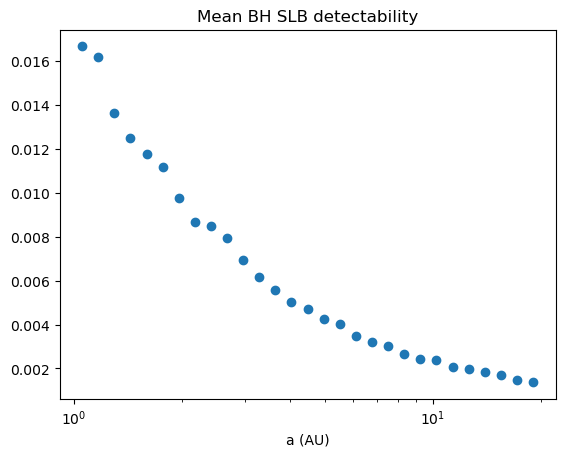

In [210]:
p = p_slb(
    r_E=r_E,
    r_star=1.0 * u.Rsun,
    a=a,
    e=e,
    f=f
)

# plt.hist(
#     a.value,
#     bins=50,
#     weights=p.value,
#     density=True
# )
# plt.scatter(a, p)
# plt.scatter(a.value, p.value, s=5, alpha=0.5)
# plt.xlabel("a (AU)")
# plt.ylabel("Probability of BH SLBs")
# plt.show()

fraction = p.mean()

print(f"{fraction:.2%} of systems are SLBs, on average")

a_sel = a.value
p_sel = p.value

bins = np.logspace(
    np.log10(a_sel.min()),
    np.log10(a_sel.max()),
    30
)

bin_centers = 0.5 * (bins[1:] + bins[:-1])

detectability = []
for i in range(len(bins) - 1):
    m = (a_sel >= bins[i]) & (a_sel < bins[i+1])
    if np.any(m):
        detectability.append(p_sel[m].mean())
    else:
        detectability.append(np.nan)

plt.scatter(bin_centers, detectability)
plt.xscale("log")
plt.xlabel("a (AU)")
plt.title("Mean BH SLB detectability")
plt.show()

0.60% of SLBs are detectable by Gaia DR4


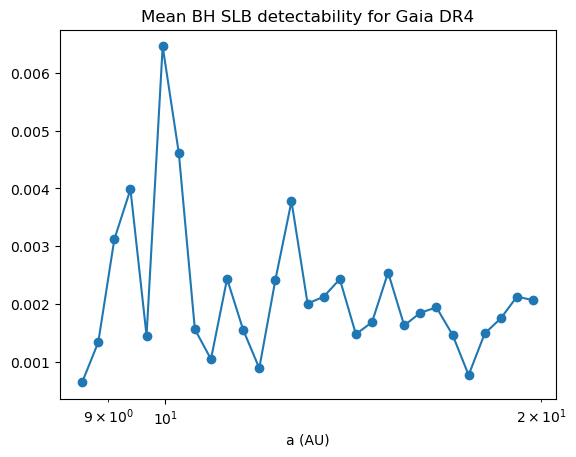

In [211]:
theta_mas = ((r_E / dlens) * u.rad).to_value(u.mas)

gaia_mask = (theta_mas > 0.01) 
gaia_fraction = p[gaia_mask]

# plt.plot(a[gaia_mask], gaia_fraction)
# plt.hist(
#     a[gaia_mask],
#     bins=50,
#     weights=gaia_fraction.value,
#     density=True
# )
# plt.xlabel("a (AU)")
# plt.ylabel("Dectactability of BH SLBs")
# plt.show()

a_sel = a[gaia_mask].value
p_sel = gaia_fraction.value

slb_dectect_4 = np.sum(gaia_mask) / p.size

print(f"{slb_dectect_4:.2%} of SLBs are detectable by Gaia DR4")

bins = np.logspace(
    np.log10(a_sel.min()),
    np.log10(a_sel.max()),
    30
)

bin_centers = 0.5 * (bins[1:] + bins[:-1])

detectability = []
for i in range(len(bins) - 1):
    m = (a_sel >= bins[i]) & (a_sel < bins[i+1])
    if np.any(m):
        detectability.append(p_sel[m].mean())
    else:
        detectability.append(np.nan)

plt.scatter(bin_centers, detectability)
plt.plot(bin_centers, detectability)
plt.xscale("log")
plt.xlabel("a (AU)")
plt.title("Mean BH SLB detectability for Gaia DR4")
plt.show()

3.29% of SLBs are detectable by Gaia DR5


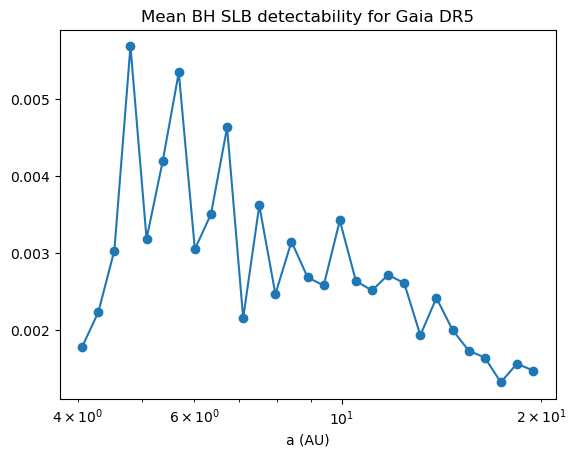

In [212]:
theta_mas = ((r_E / dlens) * u.rad).to_value(u.mas)

gaia_mask = (theta_mas > 0.007) 
gaia_fraction = p[gaia_mask]

# plt.plot(a[gaia_mask], gaia_fraction)
a_sel = a[gaia_mask].value
p_sel = gaia_fraction.value

slb_dectect_5 = np.sum(gaia_mask) / p.size

print(f"{slb_dectect_5:.2%} of SLBs are detectable by Gaia DR5")

bins = np.logspace(
    np.log10(a_sel.min()),
    np.log10(a_sel.max()),
    30
)

bin_centers = 0.5 * (bins[1:] + bins[:-1])

detectability = []
for i in range(len(bins) - 1):
    m = (a_sel >= bins[i]) & (a_sel < bins[i+1])
    if np.any(m):
        detectability.append(p_sel[m].mean())
    else:
        detectability.append(np.nan)

plt.scatter(bin_centers, detectability)
plt.plot(bin_centers, detectability)
plt.xscale("log")
plt.xlabel("a (AU)")
plt.title("Mean BH SLB detectability for Gaia DR5")
plt.show()

Binaries have revealed around 50 suspected or confirmed stellar-mass black holes in the Milky Way, but scientists think there may be as many as 100 million in our galaxy alone. (NASA)

In [213]:
100e6 * fraction * slb_dectect_4

<Quantity 3721.89002612>

In [214]:
100e6 * fraction * slb_dectect_5

<Quantity 20520.35339905>